In [15]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from model import Dendrite, Soma, Neuron
from utils import weak_event, strong_event, plot_strengths, delay_sweep, plot_delay_sweep

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
TAU_T = 60.0
TAU_E = 60.0
TAU_P = 120.0
BETA  = 0.01
S_BASE = 100.0

S_TAG = 1.0
S_EARLY = 1.0
S_PRODUCT = 1.0
W_TAG = 0.67
W_EARLY = 0.67

# Scenario 1: Strong Stimulation Alone

**Hypothesis**: Smooth progression into L-LTP due to plasticity products also increasing as a part of strong stimulation. There will be some decay

In [17]:
dendrite = Dendrite(TAU_T, TAU_E, BETA)
soma = Soma(TAU_P)
neuron = Neuron([dendrite], soma, S_BASE)

In [18]:
events = [strong_event(0, 0, S_TAG, S_EARLY, S_PRODUCT)]

t, y = neuron.run(events, 480)
(s0,) = neuron.strengths(y)

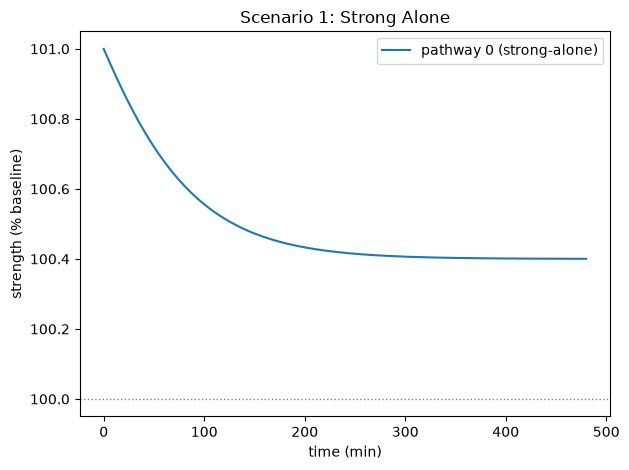

final L0 = 0.400


In [19]:
plot_strengths(t, [s0], ["pathway 0 (strong-alone)"], S_BASE, title="Scenario 1: Strong Alone")
print(f"final L0 = {y[2][-1]:.3f}")

# Scenario 2: Weak Stimulus Alone

**Hypothesis**: Without an accompanying increase in plasticity products, the early potentiation will leak to 0.

In [20]:
dendrite = Dendrite(TAU_T, TAU_E, BETA)
soma = Soma(TAU_P)
neuron = Neuron([dendrite], soma, S_BASE)

In [21]:
events = [weak_event(0, 0, S_TAG, S_EARLY)]

t, y = neuron.run(events, 480)
(s0,) = neuron.strengths(y)

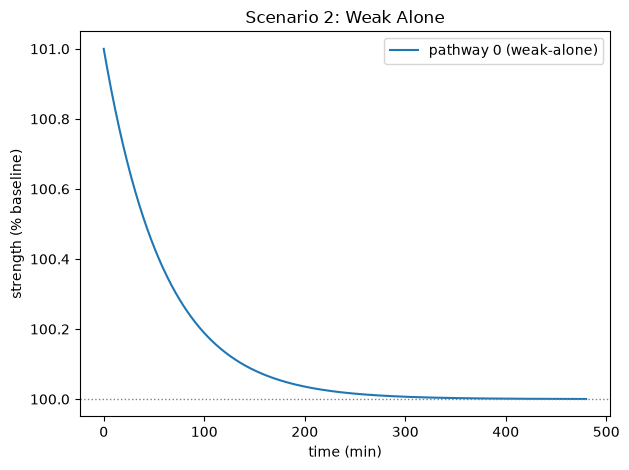

final L0 = 0.000


In [22]:
plot_strengths(t, [s0], ["pathway 0 (weak-alone)"], S_BASE, title="Scenario 2: Weak Alone")
print(f"final L0 = {y[2][-1]:.3f}")

# Scenario 3: Associative Testing

**Hypothesis**: With simultaneous strong stimulation, the weak stimulus should be able endure do to increase in plasticity products.

In [23]:
dendrite_strong = Dendrite(TAU_T, TAU_E, BETA)
dendrite_weak = Dendrite(TAU_T, TAU_E, BETA)
soma = Soma(TAU_P)
neuron = Neuron([dendrite_strong, dendrite_weak], soma, S_BASE)

In [24]:
events = [
    strong_event(0, 0, S_TAG, S_EARLY, S_PRODUCT),
    weak_event(0, 1, W_TAG, W_EARLY),
]

t, y = neuron.run(events, 480)
(s0, s1) = neuron.strengths(y)

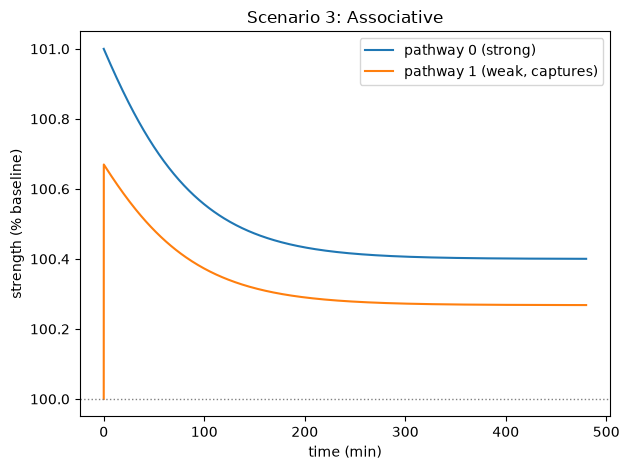

In [25]:
plot_strengths(t, [s0, s1], ["pathway 0 (strong)", "pathway 1 (weak, captures)"], S_BASE, title="Scenario 3: Associative")

# Scenario 4: Sweep Testing

**Hypothesis**: Delay between strong stimulus and weak stimulus will reduce capture effect for the weak stimulus since there will be less plasticity product.

In [26]:
delays = [0, 30, 60, 90, 120, 180, 240, 360]

In [27]:
def neuron_factory():
    return Neuron([Dendrite(TAU_T, TAU_E, BETA), Dendrite(TAU_T, TAU_E, BETA)], Soma(TAU_P), S_BASE)

s_ev = strong_event(0, 0, S_TAG, S_EARLY, S_PRODUCT)
w_ev_template = weak_event(0, 1, W_TAG, W_EARLY)

delays_out, final_L, ts, strength_curves = delay_sweep(neuron_factory, s_ev, w_ev_template, delays, end=960)

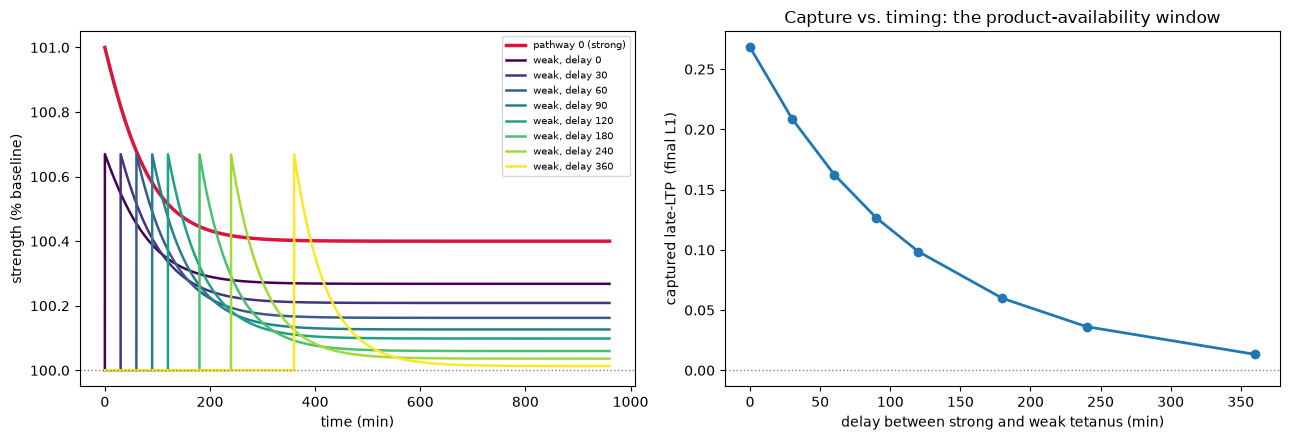

In [28]:
plot_delay_sweep(delays_out, final_L, ts, strength_curves, S_BASE)